In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [12]:
df = pd.read_csv("steam_games_feature.csv")
df.head()


,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DLC count,Supported languages,Full audio languages,Windows,...,review_log,review_balance,price_log,owners_log,is_free,main_genre,main_category,rating_gap,release_decade,is_recent
0,Galactic Bowling,2008-10-21,0 - 20000,0,0,19.99,0,['English'],[],True,...,2.890372,-0.277778,3.044046,9.21044,0,Casual,Single-player,0,2000.0,0
1,Train Bandit,2017-10-12,0 - 20000,0,0,0.99,0,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,...,4.077537,0.813559,0.688135,9.21044,0,Action,Single-player,0,2010.0,0
2,Jolt Project,2021-11-17,0 - 20000,0,0,4.99,0,"['English', 'Portuguese - Brazil']",[],True,...,0.000000,0.000000,1.790091,9.21044,0,Action,Single-player,0,2020.0,1
3,Henosis™,2020-07-23,0 - 20000,0,0,5.99,0,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,...,1.386294,0.750000,1.944481,9.21044,0,Adventure,Single-player,0,2020.0,1
4,Two Weeks in Painland,2020-02-03,0 - 20000,0,0,0.00,0,"['English', 'Spanish - Spain']",[],True,...,4.077537,0.711864,0.000000,9.21044,1,Adventure,Single-player,0,2020.0,1


In [13]:
categorical_cols = ["main_genre", "main_category"]

df = pd.get_dummies(df, columns=categorical_cols)
print("資料形狀：", df.shape)

資料形狀： (82842, 98)


In [14]:
target = "owners_log"

feature_cols = [
    "price_log", "is_free",
    "positive_rate", "review_log", "review_balance",
    "lang_count", "audio_lang_count", "audio_lang_ratio",
    "platform_count",
    "Achievements", "DLC count",
    "release_year", "release_decade", "is_recent",
    "playtime_ratio_recent"
]

# 加入 one-hot 後的類別特徵
one_hot_cols = [col for col in df.columns 
                if col.startswith("main_genre_") or col.startswith("main_category_")]

feature_cols = feature_cols + one_hot_cols

X = df[feature_cols]
y = df[target]

print("特徵數量：", X.shape[1])


特徵數量： 69


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

len(X_train), len(X_test)


(66273, 16569)

In [16]:
rf = RandomForestRegressor(
    n_estimators=300,    # 樹數量
    max_depth=20,        # 限制深度避免過度複雜
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1            # 充分利用 CPU
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [17]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("=== Random Forest Model Performance ===")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")


=== Random Forest Model Performance ===
MAE  : 0.6154
RMSE : 1.3941
R²   : 0.8362


In [18]:
# Overfitting Check: Train vs Test R²
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("=== Overfitting Check ===")
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")


=== Overfitting Check ===
Train R²: 0.9095
Test  R²: 0.8362


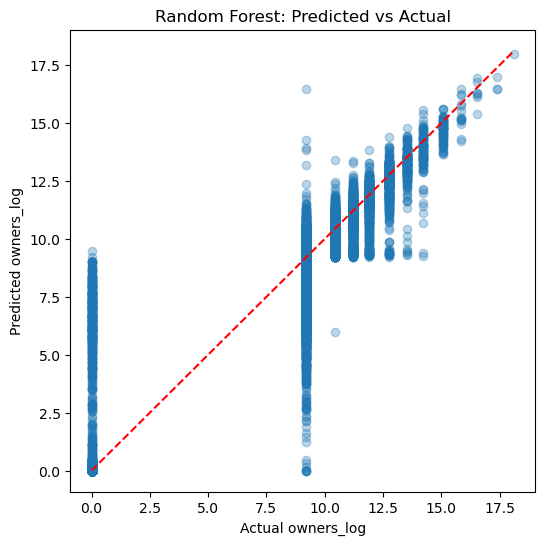

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.3)
plt.xlabel("Actual owners_log")
plt.ylabel("Predicted owners_log")
plt.title("Random Forest: Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.show()


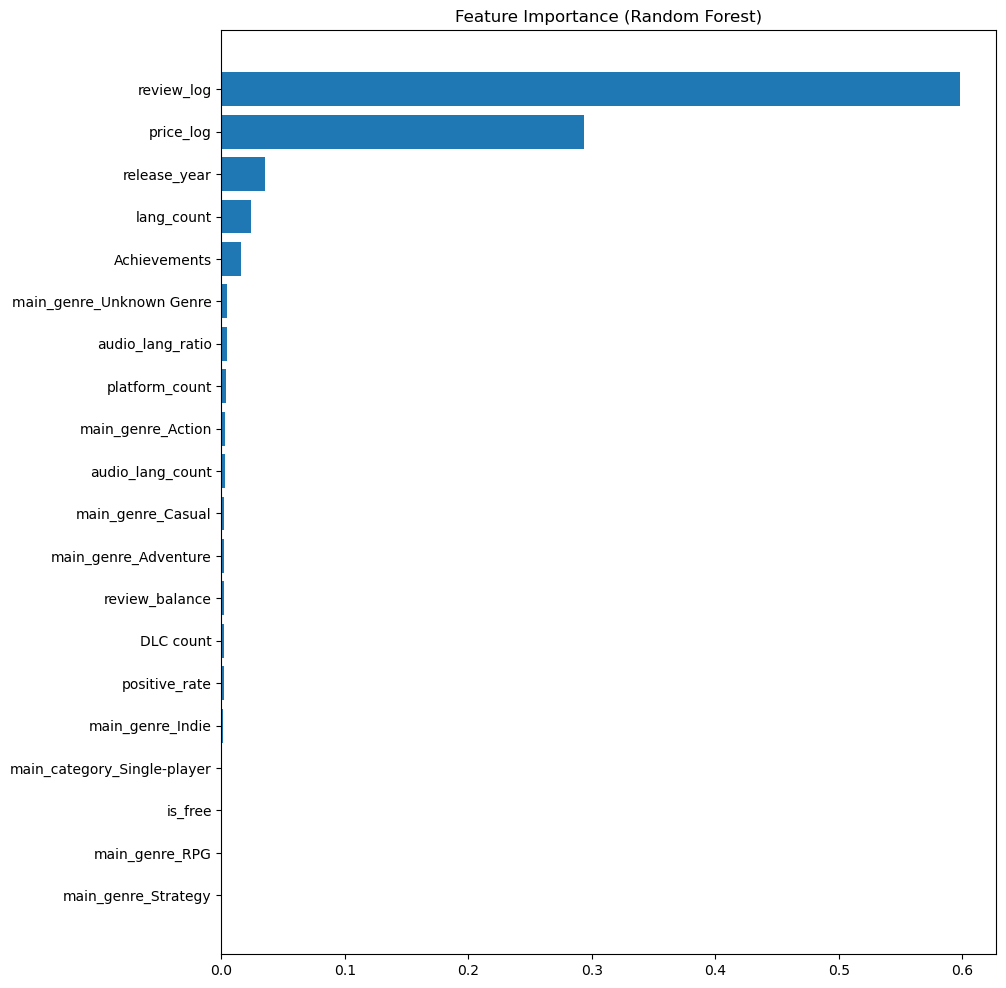

In [20]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 12))
plt.title("Feature Importance (Random Forest)")
plt.barh([X.columns[i] for i in indices[:20]], importances[indices[:20]])
plt.gca().invert_yaxis()
plt.show()
